In [1]:
# Alex Medina
# AST 5765
# Homework 8
# 31 October 2025

In [49]:
# Imports

import numpy as np
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import gaussian as g
from hw8_amedina import *

In [ ]:
print('Problem 2 \n')

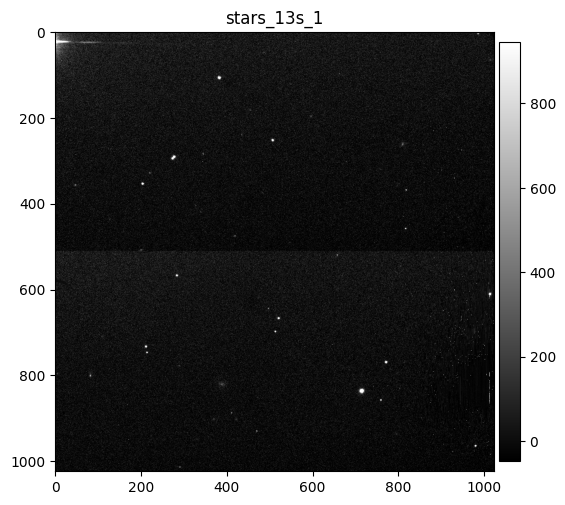

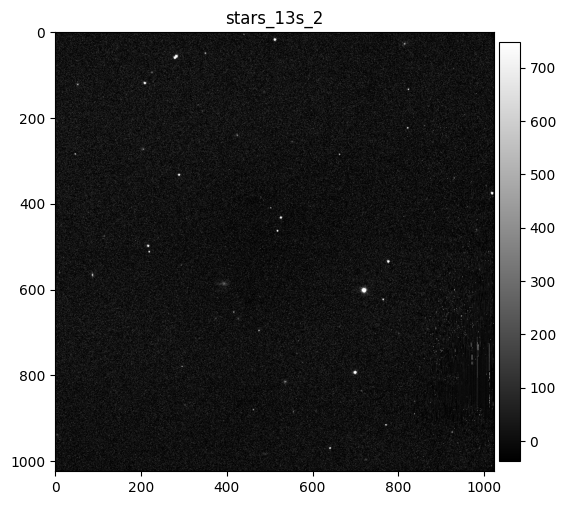

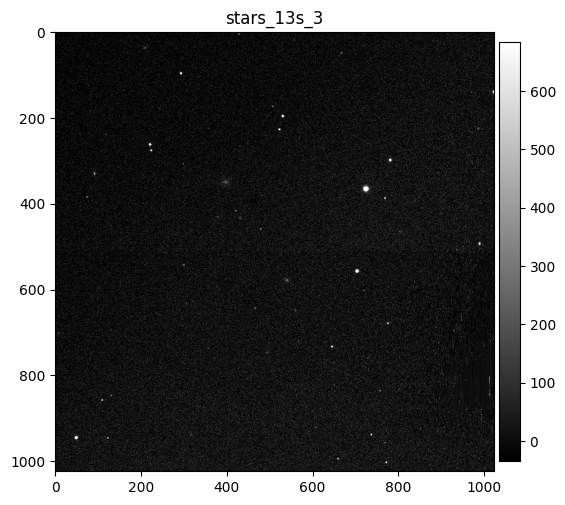

In [ ]:
# Dividing by flat

flatcalc = fits.getdata('flat.fits')

objarr /= flatcalc

# Getting the images
# Already cleaned

for i in range(3):
    qm = np.median(objarr[i])
    qs = np.std(objarr[i])
    plt.figure( figsize = (6, 6 ))
    im = plt.imshow(objarr[i], cmap='grey', vmin=qm-0.1*qs, vmax=qm+2.0*qs)
    plt.title(objfile[i])
    plt.colorbar(im, fraction=0.045, pad=0.01)

In [ ]:
# STARTING by eyeballing the alues

# Stellar photometry: 
photometry = np.array( [ # yguess, xguess, width, cy, cx, star, sky 
# star 0 
[ [ 698, 512, np.nan, np.nan, np.nan, np.nan, np.nan],  # frame 0
[464, 517, np.nan, np.nan, np.nan, np.nan, np.nan],  # frame 1
[228, 521, np.nan, np.nan, np.nan, np.nan, np.nan] ], # frame 2
# star 1 
[ [ 668, 520, np.nan, np.nan, np.nan, np.nan, np.nan],     # frame 0 
[np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], # frame 1 
[np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan] ] , # frame 2 
# star 2 
[ [ 568, 283, np.nan, np.nan, np.nan, np.nan, np.nan],           
# frame 0 
[np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],  # frame 1 
[np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]]  # frame 2 
], dtype=float) 

In [94]:
# Calculating offset

# Columns are [yguess, xguess, width, cy, cx, star, sky]
offset10 = photometry[0, 1, 0:2] - photometry[0, 0, 0:2]
offset20 = photometry[0, 2, 0:2] - photometry[0, 0, 0:2]

print(f'Offset in y and x for frame 0 to 1: {offset10}')
print(f'Offset in y and x for frame 0 to 2: {offset20}')

# Applying offsets to stars 1 and 2 based on frame 0
nstars, nframes = photometry.shape[:2]
for i in range(1, nstars):      # stars 1 and 2
    photometry[i, 1, 0:2] = photometry[i, 0, 0:2] + offset10
    photometry[i, 2, 0:2] = photometry[i, 0, 0:2] + offset20

print(photometry)

Offset in y and x for frame 0 to 1: [-234.    5.]
Offset in y and x for frame 0 to 2: [-470.    9.]
[[[698. 512.  nan  nan  nan  nan  nan]
  [464. 517.  nan  nan  nan  nan  nan]
  [228. 521.  nan  nan  nan  nan  nan]]

 [[668. 520.  nan  nan  nan  nan  nan]
  [434. 525.  nan  nan  nan  nan  nan]
  [198. 529.  nan  nan  nan  nan  nan]]

 [[568. 283.  nan  nan  nan  nan  nan]
  [334. 288.  nan  nan  nan  nan  nan]
  [ 98. 292.  nan  nan  nan  nan  nan]]]


In [ ]:
print('Problem 3a \n')

Problem 3 



In [133]:
# FIT

def fitstars(o_arr, table, subz=15):
    nstars, nframes = table.shape[:2]

    for i in range(nstars):
        for j in range(nframes):

            yguess, xguess = int(table[i, j, 0]), int(table[i, j, 1])

            # Creating subarr that's a copy
            ytop = yguess+subz+1
            ybot = yguess-subz
            xtop = xguess+subz+1
            xbot = xguess-subz

            sub = o_arr[j, ybot:ytop, xbot:xtop].copy()
            sub -= np.median(sub) # subtract median
            
            # Fitting relative to subarr (width tuple) (center tuple) (height)
            guess = ((2.0, 2.0), (yguess - ybot, xguess - xbot), np.max(sub))

            # Fit on the subimage - onlt width and center
            fw, fc, fh, fe = g.fitgaussian(sub, guess=guess)

            # Average of the two widths
            sigma_avg = float((fw[0] + fw[1]) / 2.0)

            # Fitting back to original coords
            cy, cx = float(fc[0] + ybot), float(fc[1] + xbot)

            # Write results into the table
            table[i, j, 2] = sigma_avg
            table[i, j, 3] = cy
            table[i, j, 4] = cx

    return table

# Fits 9 positions
photometry = fitstars(objarr, photometry)

# Table
print('star frame  yguess    xguess    sigma_avg    y_fit      x_fit  ')
print('-----------------------------------------------------------------')
nstars, nframes = photometry.shape[:2]
for i in range(nstars):
    for j in range(nframes):
        yg, xg = photometry[i, j, 0], photometry[i, j, 1]
        sigma  = photometry[i, j, 2]
        cy     = photometry[i, j, 3]
        cx     = photometry[i, j, 4]
        print(f"{i}     {j}     {yg}     {xg}     {sigma:.3f}      {cy:.3f}      {cx:.3f}")


star frame  yguess    xguess    sigma_avg    y_fit      x_fit  
-----------------------------------------------------------------
0     0     698.0     512.0     1.006      698.620      512.387
0     1     464.0     517.0     0.977      464.373      517.417
0     2     228.0     521.0     1.134      228.433      521.933
1     0     668.0     520.0     1.046      667.882      520.225
1     1     434.0     525.0     0.983      433.579      525.305
1     2     198.0     529.0     1.174      197.637      529.792
2     0     568.0     283.0     1.078      568.258      283.303
2     1     334.0     288.0     0.977      333.960      288.360
2     2     98.0     292.0     1.111      98.071      292.899


In [ ]:
print('Problem 3a \n')